# Even/odd as linear algebra, and the elevator you can stand on
### the parity operator $P$, its $\pm1$ eigenvalues, and $N=m(g+a)$

Two things that look unrelated are the same idea. **Even and odd functions** are
not a naming convention -- they are the $+1$ and $-1$ **eigenvectors of the parity
operator** $P:f(x)\mapsto f(-x)$. And the **AP-physics elevator problem** -- what
does a bathroom scale read while the elevator accelerates -- ends with an
acceleration profile that is *odd about the trip's midpoint*, so it integrates to
zero net velocity, for the exact same reason $\int_{-a}^{a}(\text{odd})=0$.

Uses `dgs/even_odd.py` and `dgs/elevator_scale.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import even_odd as eo, elevator_scale as ev
print("ready -- numpy", np.__version__)

ready -- numpy 2.4.4


## 1. Parity is a matrix, and it just reverses the samples

Sample a function on a grid symmetric about $0$. Then $P:f(x)\mapsto f(-x)$ does
nothing but **reverse the vector of samples** -- it is the exchange (anti-identity)
matrix. Because reversing twice gives back the original, $P^2=I$; a matrix that
squares to the identity can only have eigenvalues $\pm1$. So *every* function on
the grid is a sum of a $+1$-eigenvector (even) and a $-1$-eigenvector (odd).

In [2]:
n = 9
P = eo.parity_matrix(n)
print("P reverses samples? ", np.allclose(P @ np.arange(n), np.arange(n)[::-1]))
print("P^2 = I?           ", np.allclose(P @ P, np.eye(n)))
w = np.sort(np.linalg.eigvalsh(P))
print("eigenvalues of P:   ", np.round(w, 3))
print(f"  -> {int(np.sum(w>0))} even (+1) directions, {int(np.sum(w<0))} odd (-1)")

P reverses samples?  True
P^2 = I?            True
eigenvalues of P:    [-1. -1. -1. -1.  1.  1.  1.  1.  1.]
  -> 5 even (+1) directions, 4 odd (-1)


## 2. The projectors $E=\tfrac{I+P}{2}$, $O=\tfrac{I-P}{2}$ ARE the decomposition

Splitting $f=f_e+f_o$ is applying two **projection matrices**:
$$E=\tfrac{I+P}{2}\ (\text{even part}),\qquad O=\tfrac{I-P}{2}\ (\text{odd part}).$$
They satisfy $E^2=E$, $O^2=O$, $EO=0$, $E+O=I$ -- a complete set of orthogonal
projectors. Applying $E$ to sampled $e^x$ returns $\cosh$, applying $O$ returns
$\sinh$: the identity $e^x=\cosh x+\sinh x$ is a change of basis.

E idempotent (E@E=E)?  True
E,O orthogonal (E@O=0)? True
even part == cosh?      True
odd  part == sinh?      True


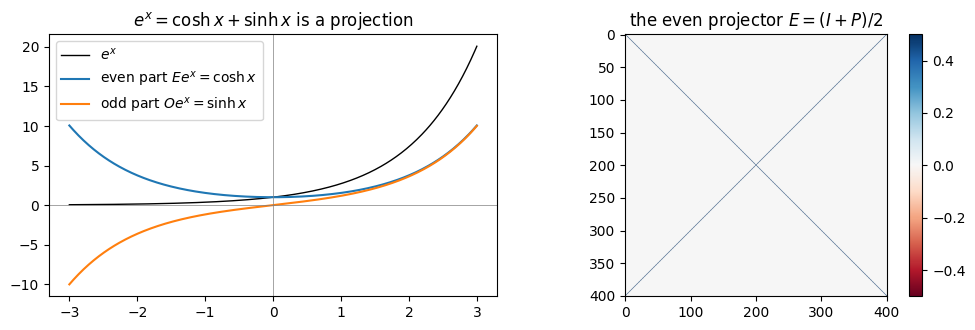

In [3]:
x = np.linspace(-3, 3, 401)
E, O = eo.parity_projectors(len(x))
fx = np.exp(x)
even, odd = E @ fx, O @ fx
print("E idempotent (E@E=E)? ", np.allclose(E @ E, E))
print("E,O orthogonal (E@O=0)?", np.allclose(E @ O, 0))
print("even part == cosh?     ", np.allclose(even, np.cosh(x)))
print("odd  part == sinh?     ", np.allclose(odd,  np.sinh(x)))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(x, fx, 'k', lw=1, label='$e^x$')
ax[0].plot(x, even, label='even part $E e^x=\\cosh x$')
ax[0].plot(x, odd,  label='odd part $O e^x=\\sinh x$')
ax[0].legend(); ax[0].set_title('$e^x=\\cosh x+\\sinh x$ is a projection')
ax[0].axhline(0, color='gray', lw=.5); ax[0].axvline(0, color='gray', lw=.5)
im = ax[1].imshow(E, cmap='RdBu', vmin=-.5, vmax=.5)
ax[1].set_title('the even projector $E=(I+P)/2$'); fig.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

## 3. The $(-1,0,1)$ stencil is ODD: differentiation flips parity

The central-difference derivative uses the stencil $\frac{1}{2h}(-1,0,+1)$ -- an
**odd** stencil. As a matrix $D$ on the symmetric grid it *anticommutes* with
parity, $PD=-DP$. That single line of algebra says **the derivative of an even
function is odd and vice versa**: $\cosh'=\sinh$ (even$\to$odd),
$\sinh'=\cosh$ (odd$\to$even). Watch the stencil turn $\cosh$ into $\sinh$.

interior PD = -DP (anticommute)? True
D cosh == sinh (even -> odd)?     True


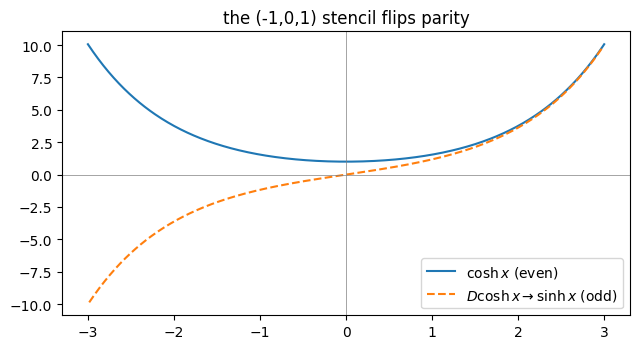

In [4]:
D = eo.central_diff_matrix(x)
anti = P_big = eo.parity_matrix(len(x))
PD_plus_DP = anti @ D + D @ anti
print("interior PD = -DP (anticommute)?", np.allclose(PD_plus_DP[1:-1], 0))
dcosh = D @ np.cosh(x)                    # apply d/dx to an EVEN vector
print("D cosh == sinh (even -> odd)?    ",
      np.max(np.abs(dcosh[1:-1] - np.sinh(x)[1:-1])) < 5e-3)

plt.figure(figsize=(6.5, 3.6))
plt.plot(x, np.cosh(x), label='$\\cosh x$ (even)')
plt.plot(x[1:-1], dcosh[1:-1], '--', label='$D\\cosh x \\to \\sinh x$ (odd)')
plt.axhline(0, color='gray', lw=.5); plt.axvline(0, color='gray', lw=.5)
plt.legend(); plt.title('the (-1,0,1) stencil flips parity'); plt.tight_layout(); plt.show()

## 4. The elevator: what does the scale read?

Stand on a bathroom scale in an elevator. The scale reads the **normal force** $N$,
not your weight $mg$. Newton's second law along the vertical gives
$$N-mg=ma \quad\Longrightarrow\quad N=m(g+a),$$
with $a>0$ upward. You feel heavy accelerating up ($N>mg$), light accelerating down
($N<mg$), and weightless in free fall ($a=-g\Rightarrow N=0$). A scale is a
*contact* force -- it cannot pull -- so the reading **clamps at zero**, never
negative.

In [5]:
m = 70.0; g = ev.G_EARTH
print(f"{m:.0f} kg rider, true weight mg = {m*g:.1f} N\n")
for label, a in [("at rest / constant v", 0.0), ("accelerate UP 3 m/s^2", 3.0),
                 ("accelerate DOWN 3 m/s^2", -3.0), ("free fall", -g),
                 ("cable snaps, rockets down", -15.0)]:
    N = float(ev.apparent_weight(m, a))
    print(f"  {label:26s}  N = {N:6.1f} N   ({float(ev.g_force(a)):.2f} g)")

70 kg rider, true weight mg = 686.7 N

  at rest / constant v        N =  686.7 N   (1.00 g)
  accelerate UP 3 m/s^2       N =  896.7 N   (1.31 g)
  accelerate DOWN 3 m/s^2     N =  476.7 N   (0.69 g)
  free fall                   N =    0.0 N   (0.00 g)
  cable snaps, rockets down   N =    0.0 N   (0.00 g)


## 5. A whole trip -- and the odd-function payoff

A smooth ride is **rest $\to$ accelerate $\to$ cruise $\to$ decelerate $\to$ rest**.
The acceleration profile is *antisymmetric about the trip's midpoint*: the push to
speed up is exactly mirrored by the pull to brake. So $\int a\,dt=0$ -- you end at
rest -- for the **same reason** an odd function's symmetric integral vanishes
($\S1$-$\S3$). Integrating $a$ once gives velocity, twice gives the floors climbed;
the scale trace reads heavy, honest, light, honest.

net velocity change: -2.32e-14 m/s  (odd a(t) integrates to 0)
floors climbed:      14.40 m


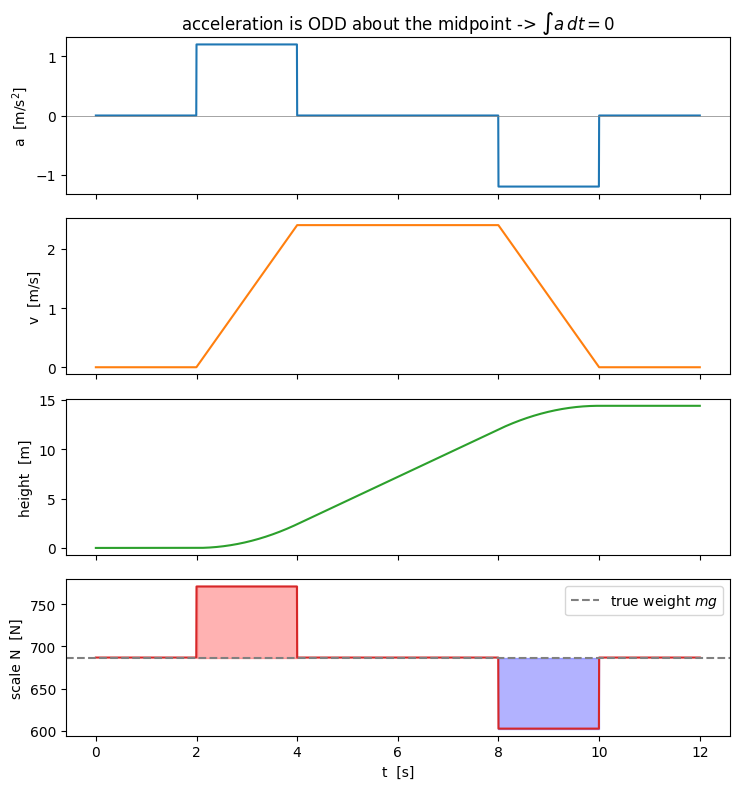

In [6]:
t = np.linspace(0, 12, 2401)
a = ev.ride_profile(t, a_max=1.2, t_acc=2.0, t_cruise=4.0)
v, y = ev.trip_kinematics(t, a)
N = ev.apparent_weight(m, a)
print(f"net velocity change: {v[-1]:.2e} m/s  (odd a(t) integrates to 0)")
print(f"floors climbed:      {y[-1]:.2f} m")

fig, ax = plt.subplots(4, 1, figsize=(7.5, 8), sharex=True)
ax[0].plot(t, a); ax[0].set_ylabel('a  [m/s$^2$]')
ax[0].set_title('acceleration is ODD about the midpoint -> $\\int a\\,dt=0$')
ax[0].axhline(0, color='gray', lw=.5)
ax[1].plot(t, v, 'C1'); ax[1].set_ylabel('v  [m/s]')
ax[2].plot(t, y, 'C2'); ax[2].set_ylabel('height  [m]')
ax[3].plot(t, N, 'C3'); ax[3].axhline(m*g, color='gray', ls='--', label='true weight $mg$')
ax[3].set_ylabel('scale N  [N]'); ax[3].set_xlabel('t  [s]'); ax[3].legend()
ax[3].fill_between(t, m*g, N, where=(N>m*g), alpha=.3, color='red',   label='heavy')
ax[3].fill_between(t, m*g, N, where=(N<m*g), alpha=.3, color='blue',  label='light')
plt.tight_layout(); plt.show()

## Takeaways

- **Even/odd is spectral.** $P:f(x)\mapsto f(-x)$ has $P^2=I$, so eigenvalues
  $\pm1$; even $=+1$ eigenspace, odd $=-1$. $f=f_e+f_o$ is the projector split
  $E=\tfrac{I+P}{2},\,O=\tfrac{I-P}{2}$.
- **Differentiation is an odd operator.** The $(-1,0,1)$ stencil obeys $PD=-DP$,
  so it flips parity: $\cosh\leftrightarrow\sinh$.
- **The scale reads $N=m(g+a)$**, clamped at $0$ (contact forces can't pull).
- **The two topics meet** in one fact: an odd acceleration profile integrates to
  zero net velocity -- the elevator returns to rest -- exactly because
  $\int_{-a}^{a}(\text{odd})=0$.